<a href="https://colab.research.google.com/github/hargagan/Machine-Learning/blob/master/Ensembles_Graded_Assessment_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# Importing 'numpy' and 'pandas' packages for working with numbers and data frames
import numpy as np
import pandas as pd

# Importing 'matplotlib.pyplot' and 'seaborn' for visualisations
from matplotlib import pyplot as plt
import seaborn as sns

# Importing packages for building ensemble models
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# Importing method for train-test split
from sklearn.model_selection import train_test_split
from sklearn.datasets import  load_breast_cancer

# Importing sutiable error measure methods
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, roc_auc_score

# Import 'GridSearchCV' for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

In [3]:
breast_cancer =  load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target)


print(f'Input shape: {X.shape}')
print(f'Class distribution:')
for i, class_name in enumerate(breast_cancer.target_names):
    count = (y == i).sum()
    print(f'  {class_name}: {count} ({count/len(y):.1%})')

Input shape: (569, 30)
Class distribution:
  malignant: 212 (37.3%)
  benign: 357 (62.7%)


In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size = 0.8, test_size=0.2, random_state = 9001, stratify=y)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((455, 30), (114, 30), (455,), (114,))

# Question 1-4 - Use RandomForestClassifier

In [22]:
# Creating a random forest classifier
# Use 100 estimators, a maximum tree depth of 4, and set the class weight as 'balanced'
# Set the random state parameter to 9001
rf = RandomForestClassifier(n_estimators = 100, max_depth = 4, class_weight = 'balanced', random_state = 9001)

# Fit the model to the training data
rf.fit(X_train, y_train);

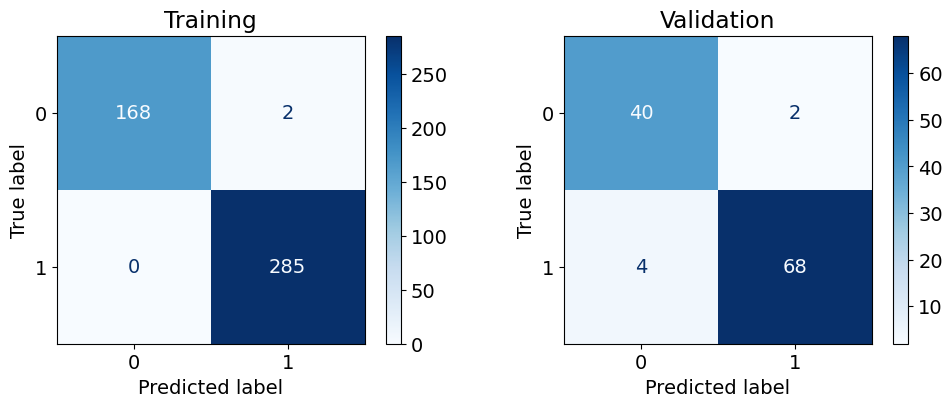

In [23]:
# Display the confusion matrices for the model on the training and validation data
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ConfusionMatrixDisplay.from_estimator(rf, X_train, y_train, cmap = plt.cm.Blues, ax = ax[0])
ConfusionMatrixDisplay.from_estimator(rf, X_val, y_val, cmap = plt.cm.Blues, ax = ax[1])
ax[0].set_title('Training')
ax[1].set_title('Validation');

In [24]:
# Obtaining predictions on the training and testing sets
y_pred_train = rf.predict(X_train)
y_pred_val = rf.predict(X_val)

# Compute accuracy scores
train_acc = accuracy_score(y_train, y_pred_train)
val_acc = accuracy_score(y_val, y_pred_val)

print('Accuracy on the training data = {}'.format(train_acc))
print('Accuracy on the validation data = {}'.format(val_acc))

Accuracy on the training data = 0.9956043956043956
Accuracy on the validation data = 0.9473684210526315


In [25]:
# Compute the ROC AUC scores for the training and the validation data
# Obtain predicted probabilities for class '1'
train_probabilities = rf.predict_proba(X_train)[:, 1]
val_probabilities = rf.predict_proba(X_val)[:, 1]

# Compute ROC AUC scores
train_auc = roc_auc_score(y_train, train_probabilities)
val_auc = roc_auc_score(y_val, val_probabilities)

print('ROC AUC score for the training data = {}'.format(train_auc))
print('ROC AUC score for the validation data = {}'.format(val_auc))

ROC AUC score for the training data = 0.9992156862745097
ROC AUC score for the validation data = 0.986111111111111


In [26]:
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



# Question 4 and 5 (Using LGBMClassifier)

In [14]:
# Create a gradient boosted tree classifier model
#Set class_weight = 'balanced'

#Set random_state = 9001 so that the results you obtain can be compared to ours

#Set verbose = -1

#Set n_estimators = 100

#Set max_depth = 2

#Set learning_rate = 0.1
gbt = LGBMClassifier(n_estimators = 100, max_depth = 2, learning_rate = 0.1, class_weight = 'balanced', random_state = 9001, verbose = -1)

# Fit the model to the training data
gbt.fit(X_train, y_train);

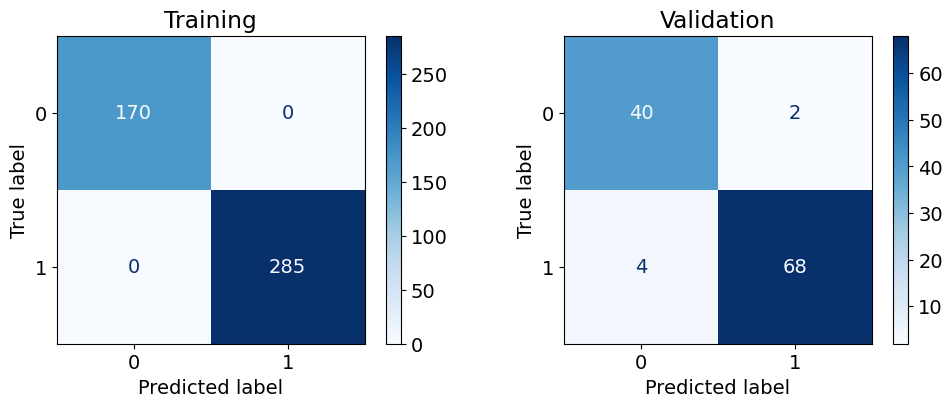

In [15]:
# Display the confusion matrices for the model on the training and validation data
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ConfusionMatrixDisplay.from_estimator(gbt, X_train, y_train, cmap = plt.cm.Blues, ax = ax[0])
ConfusionMatrixDisplay.from_estimator(gbt, X_val, y_val, cmap = plt.cm.Blues, ax = ax[1])
ax[0].set_title('Training')
ax[1].set_title('Validation');

In [16]:
# Compute the accuracy scores on the training and validation data
# Obtaining predictions
y_pred_train = gbt.predict(X_train)
y_pred_val = gbt.predict(X_val)

# Compute accuracy scores
train_acc = accuracy_score(y_train, y_pred_train)
val_acc = accuracy_score(y_val, y_pred_val)

print('Accuracy on the training data = {}'.format(train_acc))
print('Accuracy on the validation data = {}'.format(val_acc))

Accuracy on the training data = 1.0
Accuracy on the validation data = 0.9473684210526315


In [17]:
# Compute the ROC AUC scores for the training and validation data
# Obtaining predicted probabilities for class '1'
train_probabilities = gbt.predict_proba(X_train)[:, 1]
val_probabilities = gbt.predict_proba(X_val)[:, 1]

# Compute ROC AUC scores
train_auc = roc_auc_score(y_train, train_probabilities)
val_auc = roc_auc_score(y_val, val_probabilities)

print('ROC AUC score for the training data = {}'.format(train_auc))
print('ROC AUC score for the validation data = {}'.format(val_auc))

ROC AUC score for the training data = 1.0
ROC AUC score for the validation data = 0.9837962962962963


In [21]:
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

